In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Advertising (1).csv')
df

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900
...,...,...,...,...
195,38200,3700,13800,7600
196,94200,4900,8100,9700
197,177000,9300,6400,12800
198,283600,42000,66200,25500


In [5]:
df['total_spend'] = df['TV'] + df['radio'] + df['newspaper']
df = df.drop(columns=['TV', 'radio', 'newspaper'])
df

,sales,total_spend
0,22100,337100
1,10400,128900
2,9300,132400
3,18500,251300
4,12900,250000
...,...,...
195,7600,55700
196,9700,107200
197,12800,192700
198,25500,391800


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   sales        200 non-null    int64
 1   total_spend  200 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


In [7]:
df.columns

Index(['sales', 'total_spend'], dtype='object')

In [8]:
continuos = ['sales','total_spend']

In [10]:
df[continuos].describe()

,sales,total_spend
count,200.000000,200.000000
mean,14022.500000,200860.500000
std,5217.456566,92985.180587
min,1600.000000,11700.000000
25%,10375.000000,123550.000000
50%,12900.000000,207350.000000
75%,17400.000000,281125.000000
max,27000.000000,433600.000000


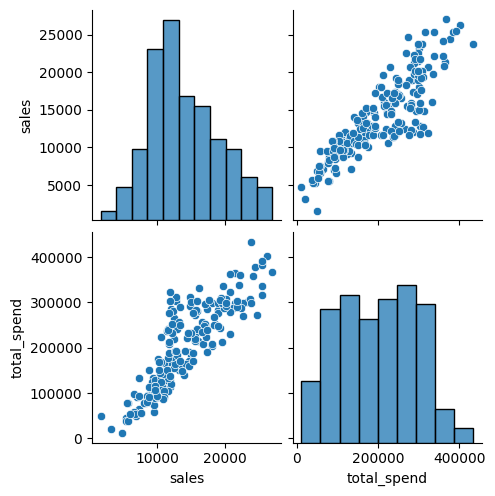

In [12]:
sns.pairplot(df)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [16]:
df[df.duplicated()]

,sales,total_spend


In [17]:
df

,sales,total_spend
0,22100,337100
1,10400,128900
2,9300,132400
3,18500,251300
4,12900,250000
...,...,...
195,7600,55700
196,9700,107200
197,12800,192700
198,25500,391800


In [18]:
df.to_csv('Advertising_cleaned.csv', index=False)

In [19]:
df = pd.read_csv('Advertising_cleaned.csv')
df

,sales,total_spend
0,22100,337100
1,10400,128900
2,9300,132400
3,18500,251300
4,12900,250000
...,...,...
195,7600,55700
196,9700,107200
197,12800,192700
198,25500,391800


In [20]:
X = df[['total_spend']]
y = df['sales']

In [34]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,train_size=0.8,random_state=77)


In [35]:
y_test

127     8800
16     12500
20     18000
90     11200
48     14800
49      9700
107     8700
170     8400
74     17000
123    15200
174    11500
149    10100
13      9700
17     24400
193    19600
154    15600
58     23800
8       4800
182     8700
191     9900
166     8000
189     6700
15     22400
156    15300
67     13400
199    13400
176    20200
111    21800
186    10300
85     15200
69     22300
43     12900
173    11700
163    18000
161    13300
22      5600
26     15000
122    11600
155     3200
151    11600
Name: sales, dtype: int64

In [36]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
print('Coefficients: ', model.coef_)
print('Intercept:',model.intercept_)

Coefficients:  [0.04784052]
Intercept: 4389.814518436082


In [38]:
import statsmodels.formula.api as smf 
model1 = smf.ols('sales ~ total_spend', data=df).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     603.4
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           5.06e-62
Time:                        11:28:45   Log-Likelihood:                -1855.4
No. Observations:                 200   AIC:                             3715.
Df Residuals:                     198   BIC:                             3721.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    4243.0282    438.525      9.676      0.000    3378.249    5107.807
total_spend     0.0487      0.002     24.564      0.000       0.045       0.053
==============================================================================
Omnibus:                        6.851   Durbin-Watson:                   1.967
Prob(Omnibus):                  0.033   Jarque-Bera (JB):                6.692
Skew:                          -0.373   Prob(JB):                       0.0352
Kurtosis:                       3.495   Cond. No.                     5.28e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.28e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
#!pip install statsmodels

^C


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 8.6 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.5 MB 9.5 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 8.5 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 8.7 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 7.3 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   --------------------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
ypred_train  = model.predict(X_train)
from sklearn.metrics import mean_squared_error, r2_score
print('Train RMSE:',np.sqrt(mean_squared_error(y_train,ypred_train)))

print('Train R2 Score:',r2_score(y_train,ypred_train))

Train RMSE: 2628.0117251844995
Train R2 Score: 0.7426281082244577


In [40]:
ypred_test = model.predict(X_test)
print('Test RMSE:',np.sqrt(mean_squared_error(y_test,ypred_test)))
print('Test R2:',r2_score(y_test,ypred_test))

Test RMSE: 2422.590173704026
Test R2: 0.7868779454628924


In [ ]:
#sales = 4389.8145 + 0.04784 * total_spend
model.predict([[100000]])

c:\Users\golla\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([9173.86699326])

In [43]:
sales = 4389.8145 + 0.04784 * 100000
sales

9173.8145